## Introduction

This tutorial demonstrates how to use TVB-Optim to fit functional connectivity (FC) data from resting-state fMRI. We use the Reduced Wong-Wang (RWW) neural mass model to simulate brain activity, convert it to BOLD signal using a hemodynamic response function, and optimize model parameters to match empirical FC patterns.

In [30]:
# Install dependencies if running in Google Colab
try:
    import google.colab
    print("Running in Google Colab - installing dependencies...")
    !pip install -q tvboptim
    print("✓ Dependencies installed!")
except ImportError:
    pass  # Not in Colab, assume dependencies are available

The workflow includes:

- Building a whole-brain network with the RWW model
- Simulating BOLD signal from neural activity
- Computing functional connectivity from BOLD
- Optimizing global and region-specific parameters to fit target FC

In [31]:
# Set up environment
import os
import time
cpu = True
if cpu:
    N = 8
    os.environ['XLA_FLAGS'] = f'--xla_force_host_platform_device_count={N}'

# Import all required libraries
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patheffects as path_effects
import jax
import jax.numpy as jnp
import copy
import optax
from scipy import io

# Jax enable x64
jax.config.update("jax_enable_x64", True)

# Import from tvboptim
from tvboptim.types import Parameter, Space, GridAxis
from tvboptim.types.stateutils import show_parameters
from tvboptim.utils import set_cache_path, cache
from tvboptim.execution import ParallelExecution, SequentialExecution
from tvboptim.optim.optax import OptaxOptimizer
from tvboptim.optim.callbacks import MultiCallback, DefaultPrintCallback, SavingCallback

# Network dynamics imports
from tvboptim.experimental.network_dynamics import Network, solve, prepare
from tvboptim.experimental.network_dynamics.dynamics.tvb import ReducedWongWang
from tvboptim.experimental.network_dynamics.coupling import LinearCoupling, FastLinearCoupling
from tvboptim.experimental.network_dynamics.graph import DenseDelayGraph, DenseGraph
from tvboptim.experimental.network_dynamics.solvers import Heun
from tvboptim.experimental.network_dynamics.noise import AdditiveNoise
from tvboptim.data import load_structural_connectivity, load_functional_connectivity

# BOLD monitoring
from tvboptim.observations.tvb_monitors.bold import Bold

# Observation functions
from tvboptim.observations.observation import compute_fc, fc_corr, rmse

# Set cache path for tvboptim
set_cache_path("./rww")

Cache stored here: /Users/Matias/TI Information Measures/cache/./rww


'/Users/Matias/TI Information Measures/cache/./rww'

We enable 64-bit precision to get reliable gradient information.

In [32]:
jax.config.update("jax_enable_x64", True)

## Loading Structural Data and Target FC

We load the Desikan-Killiany parcellation structural connectivity and empirical functional connectivity from resting-state fMRI data.

In [33]:
import sys
import urllib
import zipfile
# --- Detect environment ---
if "google.colab" in sys.modules:
    base_path = "/content/cmha_data"
else:
    base_path = os.path.join(os.getcwd(), "cmha_data")

os.makedirs(base_path, exist_ok=True)

url = "https://zenodo.org/records/10572216/files/cmha-1.0.0.zip?download=1"
zip_path = os.path.join(base_path, "cmha-1.0.0.zip")
expected_folder = os.path.join(base_path, "cmha-1.0.0")

# --- Check if already extracted ---
if os.path.exists(expected_folder):
    print(f"Dataset already extracted at: {expected_folder}")
else:
    # --- Download if missing ---
    if not os.path.exists(zip_path):
        print(f"Downloading dataset from Zenodo to {zip_path}...")
        urllib.request.urlretrieve(url, zip_path)
        print("Download complete.")
    else:
        print("Zip file already exists, skipping download.")

    # --- Extract ---
    print("Extracting files...")
    with zipfile.ZipFile(zip_path, "r") as zip_ref:
        zip_ref.extractall(base_path)
    print("\nData extracted at:", base_path)

Dataset already extracted at: /Users/Matias/TI Information Measures/cmha_data/cmha-1.0.0


In [34]:
from tvb.datatypes.connectivity import Connectivity


labels = np.genfromtxt('cmha_data/cmha-1.0.0/data/CoCoMac/labels.tsv', dtype=str, delimiter='\t', usecols=1,skip_header=1)

# Setup the Connectivity object
conn = Connectivity()

# Assign the required attributes
weights = np.loadtxt('Connectivity2/weights.txt')[:82,:82]
conn.weights = weights/np.max(weights)
conn.tract_lengths = np.loadtxt('Connectivity2/tract_lengths.txt')[:82,:82]
conn.region_labels = labels
n_nodes = weights.shape[0]
# Assign optional but recommended attributes to avoid 'None' warnings
# For the 82-region Macaque RM atlas, if you don't have coordinates:
conn.centres = np.zeros((len(labels), 3)) 
conn.cortical = np.ones(len(labels), dtype=bool) # Most CoCoMac sets are cortical

# This will now internalize the weights and calculate 'number_of_regions'
conn.configure()


In [35]:
import pandas as pd
# Load record information
record_metadata = pd.read_csv(f"{base_path}/cmha-1.0.0/data/participants.tsv",delimiter='\t')
# Load fMRI records
data_CoCoMAC = np.load(f"{base_path}/cmha-1.0.0/data/CoCoMac/timeseries.npy")

print("Subjects were recorded under 6 states",record_metadata['cond'].unique())
record_metadata.head(5)
print("\n")
print(f"Data shape {data_CoCoMAC.shape} indicates that there are 156 records from 82 brain regions with 500 samples each")
all_states = {}

for state_name in record_metadata['cond'].unique():
    all_states[state_name] = {}
    state_df = record_metadata.query("cond==@state_name")
    sub_idx = 1
    for idx, row in state_df.iterrows():
        all_states[row.cond][sub_idx] = data_CoCoMAC[idx]
        sub_idx+=1



Subjects were recorded under 6 states <StringArray>
[               'awake',             'ketamine',    'moderate-propofol',
        'deep-propofol', 'moderate-sevoflurane',     'deep-sevoflurane']
Length: 6, dtype: str


Data shape (156, 500, 82) indicates that there are 156 records from 82 brain regions with 500 samples each


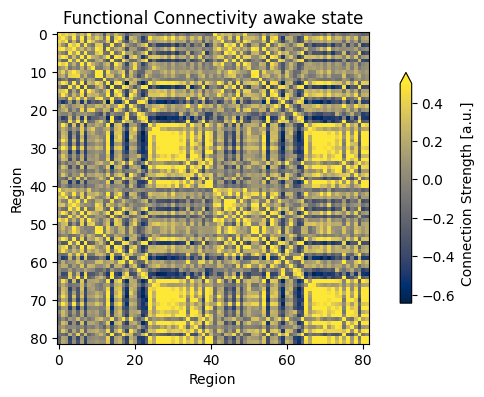

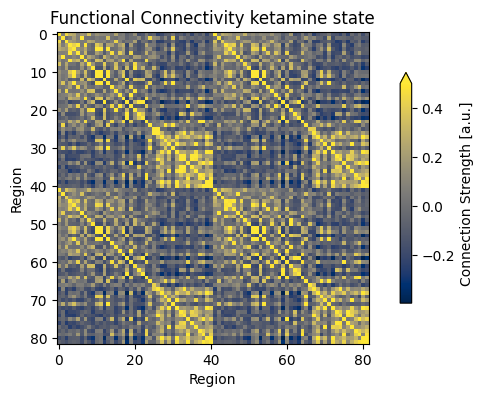

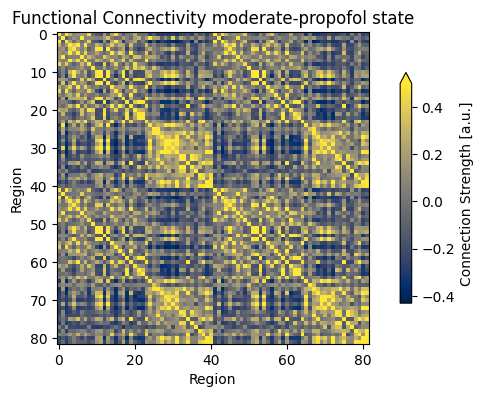

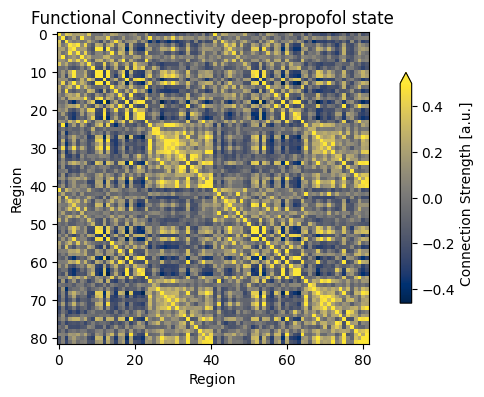

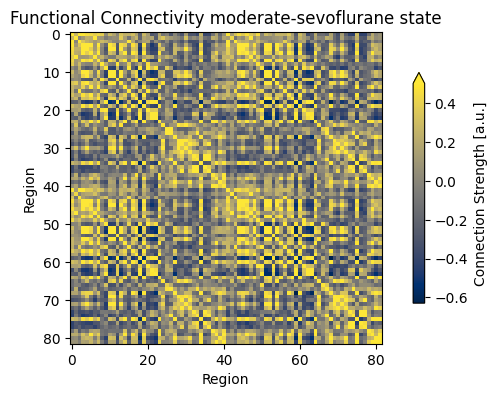

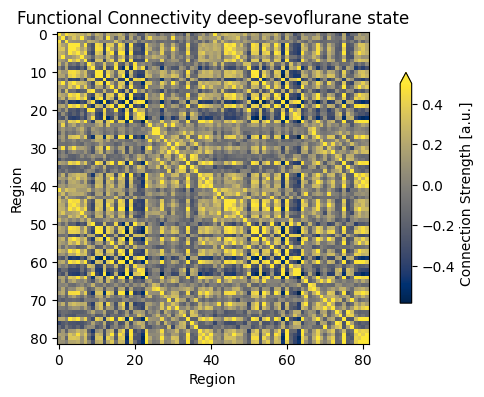

In [36]:
for state in all_states:
    emp_fc = np.mean([np.corrcoef(all_states[state][n].T) for n in all_states[state]], axis=0)
    fig, ax1 = plt.subplots(1, figsize=(8.1, 4.05), sharey=True)
    im1 = ax1.imshow(emp_fc, cmap="cividis", vmax=0.5)
    ax1.set_title(f"Functional Connectivity {state} state")
    ax1.set_xlabel("Region")
    ax1.set_ylabel("Region")
    cbar1 = fig.colorbar(im1, ax=ax1, shrink=0.74, label="Connection Strength [a.u.]", extend='max')

In [37]:
model = ReducedWongWang()

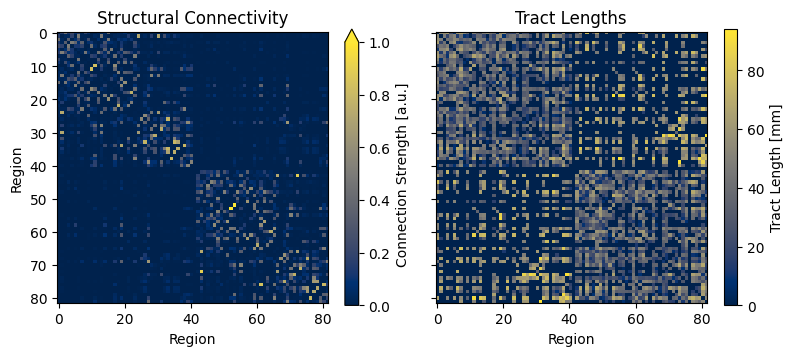

In [38]:

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(8.1, 4.05), sharey=True)
im1 = ax1.imshow(conn.weights, cmap="cividis", vmax=1)
ax1.set_title("Structural Connectivity")
ax1.set_xlabel("Region")
ax1.set_ylabel("Region")
cbar1 = fig.colorbar(im1, ax=ax1, shrink=0.74, label="Connection Strength [a.u.]", extend='max')

im2 = ax2.imshow(conn.tract_lengths, cmap="cividis")
ax2.set_title("Tract Lengths")
ax2.set_xlabel("Region")
cbar2 = fig.colorbar(im2, ax=ax2, shrink=0.74, label="Tract Length [mm]")

plt.tight_layout()

## The Reduced Wong-Wang Model

The Reduced Wong-Wang model is a biophysically-based neural mass model that describes the dynamics of NMDA-mediated synaptic gating. It captures the slow dynamics relevant for resting-state fMRI and has been widely used for modeling whole-brain functional connectivity.

The model describes the evolution of synaptic gating variable S:

$$\frac{dS}{dt} = -\frac{S}{\tau_s} + (1-S) \cdot H(x) \cdot \gamma$$

where $x = w \cdot J_N \cdot S + I_o + G \cdot c$ combines local recurrence ($w$), external input ($I_o$), and long-range coupling ($G \cdot c$), and $H(x)$ is a sigmoidal transfer function.

Key parameters:

- `w`: Excitatory recurrence strength (local feedback)
- `I_o`: External input current
- `G` (coupling strength): Global scaling of long-range connections

## Building the Network Model

We combine the RWW dynamics with structural connectivity to create a whole-brain network model.

In [39]:
# Create network components
graph = DenseGraph(conn.weights, region_labels=conn.region_labels)
dynamics = ReducedWongWang(w=0.3, I_o=0.32, INITIAL_STATE=(0.3,))
coupling = FastLinearCoupling(local_states=["S"], G=0.15)
noise = AdditiveNoise(sigma=0.00283, apply_to="S")

# Assemble the network
network = Network(
    dynamics=dynamics,
    coupling={'instant': coupling},
    graph=graph,
    noise=noise
)

## Preparing and Running the Simulation

We prepare the network for simulation and run an initial transient to reach a quasi-stationary state.

In [40]:
# Prepare simulation: compile model and initialize state
t1 = 90_000  # Total simulation duration (ms) - 2 minutes
dt = 4.0      # Integration timestep (ms)
model, state = prepare(network, Heun(), t1=t1, dt=dt)

# First simulation: run transient to reach quasi-stationary state
result_init = model(state)

# Update network with final state as new initial conditions
network.update_history(result_init)
model, state = prepare(network, Heun(), t1=t1, dt=dt)

# Second simulation: quasi-stationary dynamics
result = model(state)

## Computing BOLD Signal

We convert the neural activity (synaptic gating S) to simulated BOLD signal using a hemodynamic response function. The BOLD monitor downsamples the neural activity and convolves it with a canonical HRF kernel.

In [41]:
# Create BOLD monitor with standard parameters
bold_monitor = Bold(
    period=1000.0,          # BOLD sampling period (1 TR = 1000 ms)
    downsample_period=4.0,  # Intermediate downsampling matches dt
    voi=0,                  # Monitor first state variable (S)
    history=result_init     # Use initial state as warm start
)

# Apply BOLD monitor to simulation result
bold_result = bold_monitor(result)

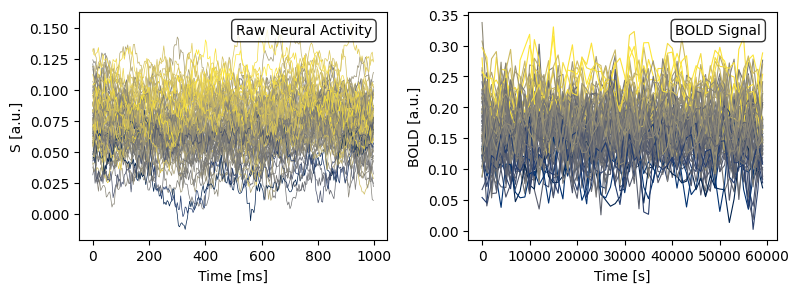

In [42]:

from matplotlib.colors import Normalize
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(8.1, 3.0375))

# Plot raw neural activity (first 1000 ms)
t_max_idx = int(1000 / dt)
time_raw = result.time[:t_max_idx]
data_raw = result.data[:t_max_idx, 0, :]

num_lines = data_raw.shape[1]
cmap = plt.cm.cividis
mean_values = np.mean(data_raw, axis=0)
norm = Normalize(vmin=np.min(mean_values), vmax=np.max(mean_values))
for i in range(num_lines):
    color = cmap(norm(mean_values[i]))
    ax1.plot(time_raw, data_raw[:, i], color=color, linewidth=0.5)

ax1.text(0.95, 0.95, "Raw Neural Activity", transform=ax1.transAxes, fontsize=10,
         ha='right', va='top', bbox=dict(boxstyle="round,pad=0.3", facecolor='white', alpha=0.8))
ax1.set_xlabel("Time [ms]")
ax1.set_ylabel("S [a.u.]")

# Plot BOLD signal (first 60 TRs)
t_bold_max = 60
time_bold = bold_result.time[:t_bold_max]
data_bold = bold_result.data[:t_bold_max, 0, :]

num_lines = data_bold.shape[1]
mean_values = np.mean(data_bold, axis=0)
norm = Normalize(vmin=np.min(mean_values), vmax=np.max(mean_values))
for i in range(num_lines):
    color = cmap(norm(mean_values[i]))
    ax2.plot(time_bold, data_bold[:, i], color=color, linewidth=0.8)

ax2.text(0.95, 0.95, "BOLD Signal", transform=ax2.transAxes, fontsize=10,
         ha='right', va='top', bbox=dict(boxstyle="round,pad=0.3", facecolor='white', alpha=0.8))
ax2.set_xlabel("Time [s]")
ax2.set_ylabel("BOLD [a.u.]")

plt.tight_layout()

## Defining Observations and Loss

Functional connectivity (FC) measures the temporal correlation between BOLD signals from different brain regions. We define an observation function that simulates BOLD and computes FC, and a loss function that quantifies the mismatch with empirical FC.

In [43]:
fc_target = np.corrcoef(all_states['awake'][1].T)
def observation(state):
    """Compute functional connectivity from simulated BOLD signal."""
    # Run simulation
    result = model(state)
    # Convert to BOLD
    bold = bold_monitor(result)
    # Compute FC, skipping first 20 TRs to avoid transient effects
    fc = compute_fc(bold, skip_t=20)
    return fc

def loss(state):
    """Compute RMSE between simulated and empirical FC."""
    fc = observation(state)
    return rmse(fc, fc_target)

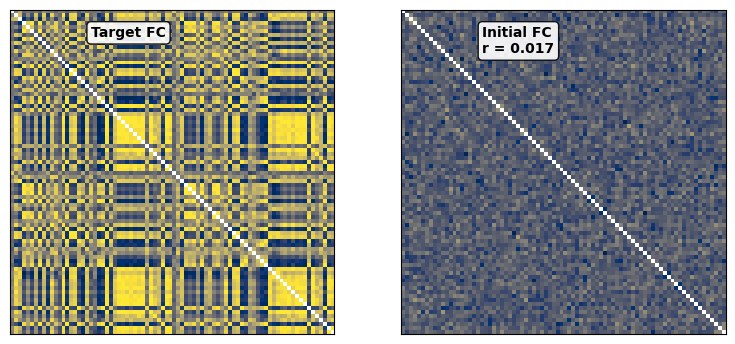

In [44]:

# Calculate initial FC
fc_initial = np.array(observation(state))

# Create figure
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(8.1, 3.54375))

# Plot both FC matrices
for ax_current, fc_matrix, title_prefix in zip([ax1, ax2], [fc_target, fc_initial], ["Target FC", "Initial FC"]):
    fc_matrix = np.copy(fc_matrix)
    np.fill_diagonal(fc_matrix, np.nan)  # Set diagonal to NaN
    im = ax_current.imshow(fc_matrix, cmap='cividis', vmax=0.9)

    ax_current.set_xticks([])
    ax_current.set_yticks([])
    ax_current.set_xlabel('')
    ax_current.set_ylabel('')

    # Calculate correlation for title
    if title_prefix == "Initial FC":
        corr_value = fc_corr(fc_initial, fc_target)
        title = f"{title_prefix}\nr = {corr_value:.3f}"
    else:
        title = title_prefix

    # Add title as annotation
    ax_current.annotate(title,
                       xy=(0.25, 0.95),
                       xycoords='axes fraction',
                       ha='left', va='top',
                       fontsize=10, fontweight='bold',
                       color='black',
                       bbox=dict(boxstyle='round,pad=0.3',
                                facecolor='white', alpha=0.9))

plt.tight_layout()

## Parameter Exploration

Before optimization, we explore how the model parameters affect FC quality. We systematically vary the excitatory recurrence `w` and global coupling strength `G` across a 2D grid and compute the loss for each combination.

In [55]:

# Create grid for parameter exploration
n = 16

# Set up parameter axes for exploration
grid_state = copy.deepcopy(state)
grid_state.dynamics.w = GridAxis(0.001, 0.7, n)
grid_state.coupling.instant.G = GridAxis(0.001, 0.7, n)

# Create space (product creates all combinations of w and G)
grid = Space(grid_state, mode="product")

@cache("explore", redo=True)
def explore():
    # Parallel execution across 8 processes
    exec = ParallelExecution(loss, grid)
    # Alternative: Sequential execution
    # exec = SequentialExecution(loss, grid)
    return exec.run()

exploration_results = explore()

Running computations for explore


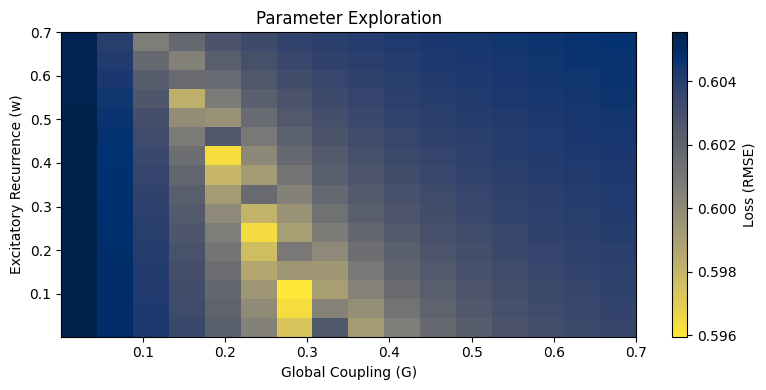

In [56]:

# Prepare data for visualization
pc = grid.collect()
G_vals = pc.coupling.instant.G.flatten()
w_vals = pc.dynamics.w.flatten()

# Get parameter ranges
G_min, G_max = min(G_vals), max(G_vals)
w_min, w_max = min(w_vals), max(w_vals)

# Create figure and axis
fig, ax = plt.subplots(figsize=(8, 4))

# Create the heatmap
im = ax.imshow(jnp.stack(exploration_results).reshape(n, n).T,
              cmap='cividis_r',
              extent=[G_min, G_max, w_min, w_max],
              origin='lower',
              aspect='auto',
              interpolation='none')

# Add colorbar and labels
cbar = plt.colorbar(im, label="Loss (RMSE)")
ax.set_xlabel('Global Coupling (G)')
ax.set_ylabel('Excitatory Recurrence (w)')
ax.set_title("Parameter Exploration")

plt.tight_layout()

## Gradient-Based Optimization

We use gradient-based optimization to find the best global parameters (same values for all regions) that minimize the FC mismatch. JAX's automatic differentiation computes gradients through the entire simulation pipeline.

In [57]:

# Mark parameters as optimizable
state.coupling.instant.G = Parameter(state.coupling.instant.G)
state.dynamics.w = Parameter(state.dynamics.w)
# Create and run optimizer
cb = MultiCallback([
    DefaultPrintCallback(every=10),
    SavingCallback(key="state", save_fun=lambda *args: args[1])  # Save updated state
])

@cache("optimize", redo=True)
def optimize():
    opt = OptaxOptimizer(loss, optax.adam(0.01), callback=cb)
    fitted_state, fitting_data = opt.run(state, max_steps=1000)
    return fitted_state, fitting_data

fitted_state, fitting_data = optimize()

Running computations for optimize
Step 0: 0.601976
Step 10: 0.596452
Step 20: 0.596185
Step 30: 0.596088
Step 40: 0.596096
Step 50: 0.596080
Step 60: 0.596071
Step 70: 0.596066
Step 80: 0.596061
Step 90: 0.596055
Step 100: 0.596050
Step 110: 0.596044
Step 120: 0.596038
Step 130: 0.596032
Step 140: 0.596026
Step 150: 0.596019
Step 160: 0.596013
Step 170: 0.596007
Step 180: 0.596000
Step 190: 0.595994
Step 200: 0.595988
Step 210: 0.595982
Step 220: 0.595975
Step 230: 0.595969
Step 240: 0.595963
Step 250: 0.595956
Step 260: 0.595950
Step 270: 0.595944
Step 280: 0.595938
Step 290: 0.595932
Step 300: 0.595926
Step 310: 0.595920
Step 320: 0.595914
Step 330: 0.595908
Step 340: 0.595902
Step 350: 0.595897
Step 360: 0.595891
Step 370: 0.595885
Step 380: 0.595880
Step 390: 0.595874
Step 400: 0.595869
Step 410: 0.595863
Step 420: 0.595858
Step 430: 0.595853
Step 440: 0.595847
Step 450: 0.595842
Step 460: 0.595837
Step 470: 0.595832
Step 480: 0.595827
Step 490: 0.595822
Step 500: 0.595817
Step 510

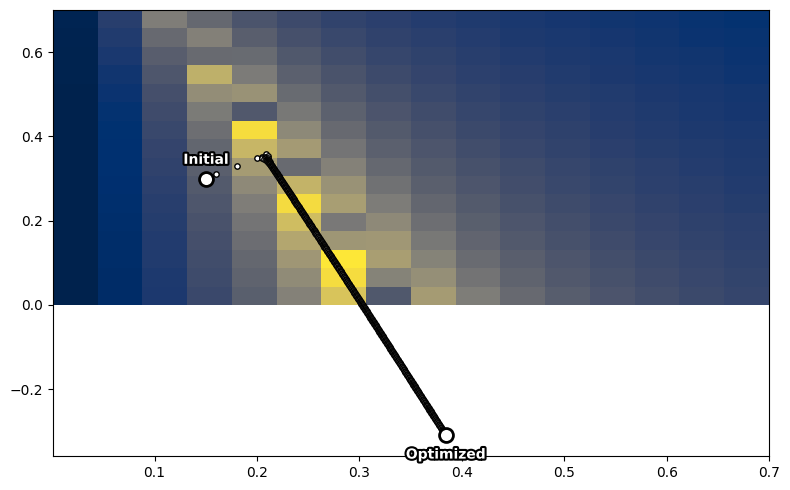

In [67]:

# Prepare data for visualization
pc = grid.collect()
G_vals = pc.coupling.instant.G
w_vals = pc.dynamics.w

# Get parameter ranges
G_min, G_max = min(G_vals), max(G_vals)
w_min, w_max = min(w_vals), max(w_vals)

# Create figure and axis
fig, ax = plt.subplots(figsize=(8, 5))

# Create the heatmap
im = ax.imshow(jnp.stack(exploration_results).reshape(n, n).T,
               cmap='cividis_r',
               extent=[G_min, G_max, w_min, w_max],
               origin='lower',
               aspect='auto',
               interpolation='none')

# Mark initial value
G_init = state.coupling.instant.G.value
w_init = state.dynamics.w.value
ax.scatter(G_init, w_init, color='white', s=100, marker='o',
           edgecolors='k', linewidths=2, zorder=5)

# Add annotation
ax.annotate('Initial', xy=(G_init, w_init),
            xytext=(G_init, w_init+0.05*(w_max-w_min)),
            color='white', fontweight='bold', ha='center', zorder=5,
            path_effects=[path_effects.withStroke(linewidth=3, foreground='black')])

# Add fitted value point
G_fit = fitted_state.coupling.instant.G.value
w_fit = fitted_state.dynamics.w.value
ax.scatter(G_fit, w_fit, color='white', s=100, marker='o',
           edgecolors='k', linewidths=2, zorder=5)

# Add annotation for the fitted value
ax.annotate('Optimized', xy=(G_fit, w_fit),
            xytext=(G_fit, w_fit-0.08*(w_max-w_min)),
            color='white', fontweight='bold', ha='center', zorder=5,
            path_effects=[path_effects.withStroke(linewidth=3, foreground='black')])

# Add optimization path points
G_route = np.array([ds.coupling.instant.G.value for ds in fitting_data["state"].save])
w_route = np.array([ds.dynamics.w.value for ds in fitting_data["state"].save])
ax.scatter(G_route[::2], w_route[::2], color='white', s=15, marker='o',
           linewidths=1, zorder=4, edgecolors='k')

# Remove axes ticks and labels
# ax.set_xticks([])
# ax.set_yticks([])
ax.set_xlabel('')
ax.set_ylabel('')

plt.tight_layout()

## Heterogeneous Optimization

Global parameters (same for all regions) may not capture region-specific variations needed for optimal FC fit. We now make parameters heterogeneous: each brain region gets its own `w` and `I_o` values, while keeping `G` global.

In [59]:
# Copy already optimized state and make parameters regional
fitted_state_het = copy.deepcopy(fitted_state)

# Make w regional (one value per node)
fitted_state_het.dynamics.w.shape = (82,)

# Also make I_o regional and mark as optimizable
fitted_state_het.dynamics.I_o = Parameter(fitted_state_het.dynamics.I_o)
fitted_state_het.dynamics.I_o.shape = (82,)

# Keep global coupling fixed at optimized value
fitted_state_het.coupling.instant.G = fitted_state_het.coupling.instant.G.value

show_parameters(fitted_state_het)

Parameters
├── _internal: Bunch
├── coupling: Bunch
├── dynamics
│   ├── I_o
│   │   └── value: [0.32 0.32 0.32 0.32 0.32 0.32 0.32 0.32 0.32 0.32 0.32 0.32 0.32 0.32
 0.32 0.32 0.32 0.32 0.32 0.32 0.32 0.32 0.32 0.32 0.32 0.32 0.32 0.32
 0.32 0.32 0.32 0.32 0.32 0.32 0.32 0.32 0.32 0.32 0.32 0.32 0.32 0.32
 0.32 0.32 0.32 0.32 0.32 0.32 0.32 0.32 0.32 0.32 0.32 0.32 0.32 0.32
 0.32 0.32 0.32 0.32 0.32 0.32 0.32 0.32 0.32 0.32 0.32 0.32 0.32 0.32
 0.32 0.32 0.32 0.32 0.32 0.32 0.32 0.32 0.32 0.32 0.32 0.32]
│   └── w
│       └── value: [-0.30861997 -0.30861997 -0.30861997 -0.30861997 -0.30861997 -0.30861997
 -0.30861997 -0.30861997 -0.30861997 -0.30861997 -0.30861997 -0.30861997
 -0.30861997 -0.30861997 -0.30861997 -0.30861997 -0.30861997 -0.30861997
 -0.30861997 -0.30861997 -0.30861997 -0.30861997 -0.30861997 -0.30861997
 -0.30861997 -0.30861997 -0.30861997 -0.30861997 -0.30861997 -0.30861997
 -0.30861997 -0.30861997 -0.30861997 -0.30861997 -0.30861997 -0.30861997
 -0.30861997 -0.3086

In [60]:

@cache("optimize_het", redo=True)
def optimize_het():
    opt = OptaxOptimizer(loss, optax.adam(0.004, b2=0.999), callback=cb)
    fitted_state, fitting_data = opt.run(fitted_state_het, max_steps=2000)
    return fitted_state, fitting_data

fitted_state_het, fitting_data_het = optimize_het()

Running computations for optimize_het


Step 0: 0.595614
Step 10: 0.569933
Step 20: 0.555848
Step 30: 0.543886
Step 40: 0.534563
Step 50: 0.527182
Step 60: 0.520215
Step 70: 0.550276
Step 80: 0.530754
Step 90: 0.529781
Step 100: 0.518620
Step 110: 0.515091
Step 120: 0.510046
Step 130: 0.530584
Step 140: 0.534867
Step 150: 0.519162
Step 160: 0.503509
Step 170: 0.509867
Step 180: 0.501554
Step 190: 0.505369
Step 200: 0.523998
Step 210: 0.502675
Step 220: 0.509905
Step 230: 0.498361
Step 240: 0.513389
Step 250: 0.530476
Step 260: 0.512960
Step 270: 0.504635
Step 280: 0.493774
Step 290: 0.502156
Step 300: 0.496885
Step 310: 0.491581
Step 320: 0.503357
Step 330: 0.497302
Step 340: 0.509093
Step 350: 0.507052
Step 360: 0.504555
Step 370: 0.499940
Step 380: 0.510839
Step 390: 0.505620
Step 400: 0.490463
Step 410: 0.493471
Step 420: 0.491262
Step 430: 0.491857
Step 440: 0.494045
Step 450: 0.492396
Step 460: 0.495028
Step 470: 0.504786
Step 480: 0.489089
Step 490: 0.502746
Step 500: 0.500820
Step 510: 0.508534
Step 520: 0.496997
Step

## Comparing Global vs Regional Parameters

Let's compare the FC quality from global (homogeneous) vs regional (heterogeneous) parameter fits.

In [61]:
# Compute FC for both optimization strategies
fc_global = np.array(observation(fitted_state))
fc_regional = np.array(observation(fitted_state_het))

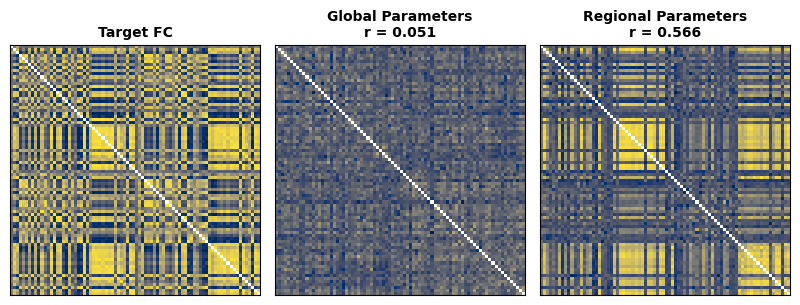

In [62]:

# Create the figure with three subplots
fig, (ax1, ax2, ax3) = plt.subplots(1, 3, figsize=(8.1, 3.54375))

# Plot the FC matrices
for ax_current, fc_matrix, title_prefix in zip([ax1, ax2, ax3], [fc_target, fc_global, fc_regional], ["Target FC", "Global Parameters", "Regional Parameters"]):
    fc_matrix = np.copy(fc_matrix)
    np.fill_diagonal(fc_matrix, np.nan)  # Set diagonal to NaN
    im = ax_current.imshow(fc_matrix, cmap='cividis', vmax=1.0)

    ax_current.set_xticks([])
    ax_current.set_yticks([])
    ax_current.set_xlabel('')
    ax_current.set_ylabel('')

    # Calculate correlation for title (if not target)
    if title_prefix == "Target FC":
        title = title_prefix
    elif title_prefix == "Global Parameters":
        corr_value = fc_corr(fc_global, fc_target)
        title = f"{title_prefix}\nr = {corr_value:.3f}"
    else:
        corr_value = fc_corr(fc_regional, fc_target)
        title = f"{title_prefix}\nr = {corr_value:.3f}"

    # Set title
    ax_current.set_title(title, fontsize=10, fontweight='bold')

plt.tight_layout()

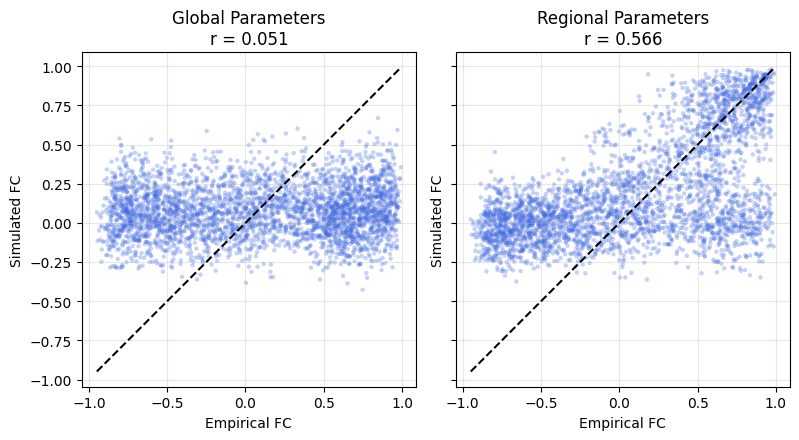

In [63]:

# Create figure with two scatter plots
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(8.1, 5.4), sharey=True, sharex=True)

# Get upper triangular indices (exclude diagonal)
triu_idx = np.triu_indices_from(fc_target, k=1)

# Extract upper triangular values
fc_target_triu = fc_target[triu_idx]
fc_global_triu = fc_global[triu_idx]
fc_regional_triu = fc_regional[triu_idx]

# Plot global parameters
ax1.scatter(fc_target_triu, fc_global_triu, alpha=0.3, s=10, color='royalblue', edgecolors='none')
ax1.plot([fc_target_triu.min(), fc_target_triu.max()],
         [fc_target_triu.min(), fc_target_triu.max()],
         'k--', linewidth=1.5, label='Perfect fit')
corr_global = fc_corr(fc_global, fc_target)
ax1.set_xlabel('Empirical FC')
ax1.set_ylabel('Simulated FC')
ax1.set_title(f'Global Parameters\nr = {corr_global:.3f}')
ax1.grid(True, alpha=0.3)
ax1.set_aspect('equal', adjustable='box')

# Plot regional parameters
ax2.scatter(fc_target_triu, fc_regional_triu, alpha=0.3, s=10, color='royalblue', edgecolors='none')
ax2.plot([fc_target_triu.min(), fc_target_triu.max()],
         [fc_target_triu.min(), fc_target_triu.max()],
         'k--', linewidth=1.5, label='Perfect fit')
corr_regional = fc_corr(fc_regional, fc_target)
ax2.set_xlabel('Empirical FC')
ax2.set_ylabel('Simulated FC')
ax2.set_title(f'Regional Parameters\nr = {corr_regional:.3f}')
ax2.grid(True, alpha=0.3)
ax2.set_aspect('equal', adjustable='box')

plt.tight_layout()

## Fitted Heterogeneous Parameters

Let's examine the fitted region-specific parameters and their relationship to structural connectivity.

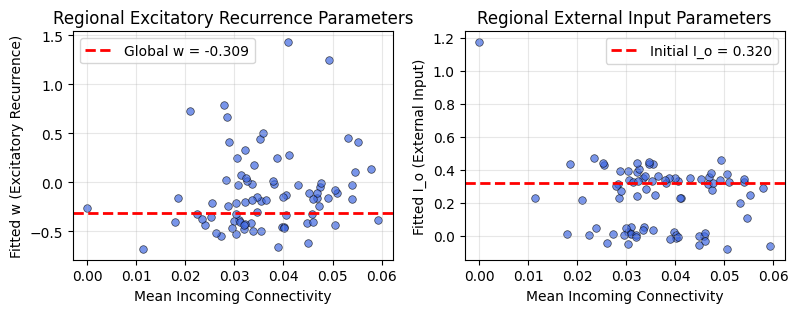

In [64]:

# Calculate mean incoming connectivity for each region
mean_connectivity = np.mean(conn.weights, axis=1)

# Extract fitted regional parameters
w_fitted = fitted_state_het.dynamics.w.value.flatten()
I_o_fitted = fitted_state_het.dynamics.I_o.value.flatten()

# Get global optimization values for reference
w_global = fitted_state.dynamics.w.value
I_o_global = fitted_state.dynamics.I_o  # Not optimized in global fit, but initial value

# Create figure
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(8.1, 3.24))

# Plot w vs mean connectivity
ax1.scatter(mean_connectivity, w_fitted, alpha=0.7, s=30, color='royalblue', edgecolors='k', linewidths=0.5)
ax1.axhline(w_global, color='red', linestyle='--', linewidth=2, label=f'Global w = {w_global:.3f}')
ax1.set_xlabel('Mean Incoming Connectivity')
ax1.set_ylabel('Fitted w (Excitatory Recurrence)')
ax1.set_title('Regional Excitatory Recurrence Parameters')
ax1.legend(loc='best')
ax1.grid(True, alpha=0.3)

# Plot I_o vs mean connectivity
ax2.scatter(mean_connectivity, I_o_fitted, alpha=0.7, s=30, color='royalblue', edgecolors='k', linewidths=0.5)
ax2.axhline(I_o_global, color='red', linestyle='--', linewidth=2, label=f'Initial I_o = {I_o_global:.3f}')
ax2.set_xlabel('Mean Incoming Connectivity')
ax2.set_ylabel('Fitted I_o (External Input)')
ax2.set_title('Regional External Input Parameters')
ax2.legend(loc='best')
ax2.grid(True, alpha=0.3)

plt.tight_layout()